In [38]:
# Imports ALL neccessary libraries
import matplotlib.pyplot as plt
import math
import numpy as np

In [39]:
# Function that helps compute the fold count needed to exceed Mt. Everest
# given paper thickness in mm
def exceed_mount_everest(paper_thickness_in_mm: float) -> float:
  height_of_mount_everest_in_meters = 8848
  paper_thickness_in_meters = paper_thickness_in_mm / 1000
  calculated_thickness_height = 0
  calculated_fold_count = 1
  while(calculated_thickness_height < height_of_mount_everest_in_meters):
    calculated_thickness_height = 2**calculated_fold_count * paper_thickness_in_meters
    if calculated_thickness_height > height_of_mount_everest_in_meters:
      break
    calculated_fold_count += 1

  return calculated_fold_count

In [40]:
paper_thickness_in_mm = 0.1
tissue_paper_thickness_in_mm = 0.05
card_stock_thickness_in_mm = 0.3
# ANS: Q1(a) ==> How many folds does it take to exceed the height of Mount Everest at 8,848 m?
print(exceed_mount_everest(paper_thickness_in_mm))
print(exceed_mount_everest(tissue_paper_thickness_in_mm))
print(exceed_mount_everest(card_stock_thickness_in_mm))

27
28
25


ANS Q1(b): Observation on how my answer changes across different paper types


1.   It is observed that as paper thickness reduces, the number of folds increases. Hence, the thickness, t, of a paper is inversely proportinal to the number of folds required to exceed mount everest.


In [41]:
# Q1(c) ==> Function that helps get initial thickness given number of folds
def get_initial_thickness(no_of_folds: int) -> float:
  height_of_mount_everest_in_meters = 8848
  # using the formula of initial_thickness_in_meters * 2**no_of_folds = height_of_mount_everest_in_meters
  # initial_thickness_in_meters = height_of_mount_everest_in_meters / 2**no_of_folds
  initial_thickness_in_meters = height_of_mount_everest_in_meters / 2**no_of_folds
  return initial_thickness_in_meters * 1000

In [42]:
# ANS: Q1(c) ==> At what initial thickness would exactly 20 folds be enough?
print(get_initial_thickness(20))
# Proof to Q1(c) ANS: To verify that get_initial_thickness works, the below method was tested using the output of the get_initial_thickness method
print(exceed_mount_everest(8.438))


8.4381103515625
21


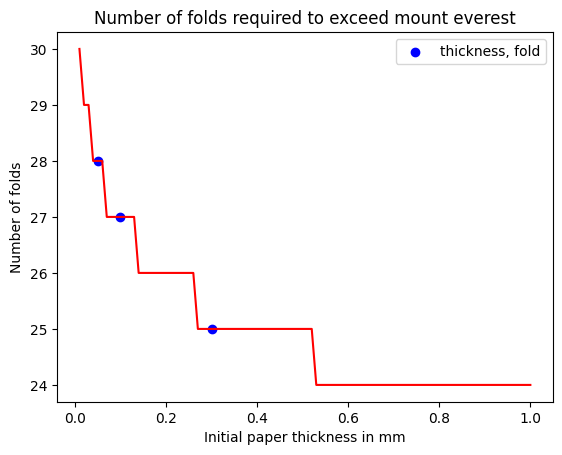

In [43]:
# ANS: Q1(d) ==> Plot the number of folds required as a function of paper thickness, mark all 3
# thickness and their folds, and explain what the shape of that curve tells you
thickness_range = np.linspace(0.01, 1, 100)
thickness_fold = np.vectorize(exceed_mount_everest)(thickness_range)
plt.plot(thickness_range, thickness_fold, color='red')
map_thicknesses = [tissue_paper_thickness_in_mm, paper_thickness_in_mm, card_stock_thickness_in_mm]
map_folds = [exceed_mount_everest(map_thicknesses[0]),exceed_mount_everest(map_thicknesses[1]),exceed_mount_everest(map_thicknesses[2])]
plt.scatter(map_thicknesses, map_folds, color='blue', label='thickness, fold')
plt.ylabel('Number of folds')
plt.xlabel('Initial paper thickness in mm')
plt.title('Number of folds required to exceed mount everest')
plt.legend()

In [44]:
def t_to_drop_below_x_percent(percentage_threshold: float, a: float) -> float:
  # Using the formular v(t)=v(0)exp(-at)
  # Where:
  #   v(t) is the volume of water as a function of time t
  #   v(0) is the initial volume of water at t = 0
  #   a is the decay constant
  #   t is the time in days
  # Going by the formular, to find the amount of time t for the initial
  # volume of water to fall below a percentage threshold, t becomes

  t = math.log(percentage_threshold/100) / -a
  return t


In [45]:
print(t_to_drop_below_x_percent(50,0.05))
print(t_to_drop_below_x_percent(10,0.05))
print(t_to_drop_below_x_percent(9,0.05))
print(t_to_drop_below_x_percent(50,0.15))
print(t_to_drop_below_x_percent(10,0.15))
print(t_to_drop_below_x_percent(9,0.15))

13.862943611198904
46.05170185988091
48.15891217303744
4.620981203732969
15.350567286626971
16.052970724345816


Assuming that the reservoir has a uniform cross-section and the discharge valve that
gets water out of the tank is positioned at 10% of the height of the reservoir,
one can deduce that at 10% of the initial volume, the discharge pressure has
reduced significantly that only droplets of water would come out.
However, just slightly below the 10% (9%) of the height where the discharge valve
is positioned, the reservior becomes effectively unable to discharge water.
Hence, the reservoir becomes effectively empty at 9% of the initial volume.
It will take 48.15 days for the reservoir to attain that volume depreciation.

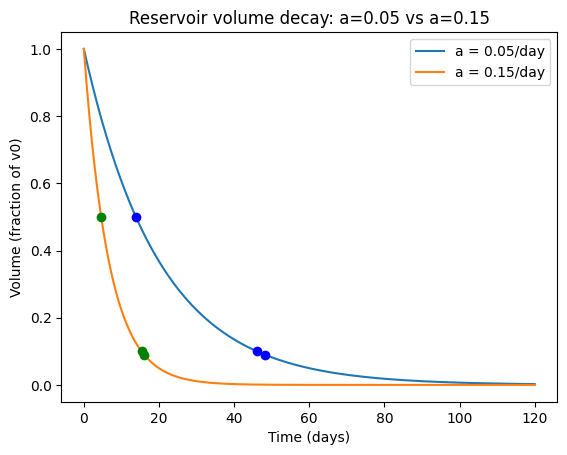

In [46]:
# The actual decay curves, evaluated over a range of time
t_range = np.linspace(0, 120, 500)
v0 = 1

v_a05 = v0 * np.exp(-0.05 * t_range)
v_a15 = v0 * np.exp(-0.15 * t_range)

plt.plot(t_range, v_a05, label='a = 0.05/day')
plt.plot(t_range, v_a15, label='a = 0.15/day')

# Mark the threshold points on the curves
t_thresholds_a05 = [t_to_drop_below_x_percent(50, 0.05), t_to_drop_below_x_percent(10, 0.05), t_to_drop_below_x_percent(9, 0.05)]
v_thresholds = [0.5, 0.10, 0.09]  # the corresponding volume fractions

plt.scatter(t_thresholds_a05, v_thresholds, color='blue', zorder=5)

t_thresholds_a15 = [t_to_drop_below_x_percent(50, 0.15), t_to_drop_below_x_percent(10, 0.15), t_to_drop_below_x_percent(9, 0.15)]
plt.scatter(t_thresholds_a15, v_thresholds, color='green', zorder=5)

plt.xlabel('Time (days)')
plt.ylabel('Volume (fraction of v0)')
plt.title('Reservoir volume decay: a=0.05 vs a=0.15')
plt.legend()
plt.show()

In [47]:
# Computes compound interests and balance given P, R and T
def compute_compound_interest(principal: float, interest_rate_in_percentage: float, time_in_years: int) -> float:
  return principal * (1 + interest_rate_in_percentage/100)**time_in_years

In [48]:
# ANS: Q3(a) ==> Calculate the balance after 1, 2, 3, 4, and 5 years. Show your working
print(compute_compound_interest(500, 5, 1))
print(compute_compound_interest(500, 5, 2))
print(compute_compound_interest(500, 5, 3))
print(compute_compound_interest(500, 5, 4))
print(compute_compound_interest(500, 5, 5))

525.0
551.25
578.8125000000001
607.7531250000001
638.1407812500001


In [49]:
# Given the current savings rate of two banks operating in Rwanda::
# 1. I&M Bank: 9.5% per annum - https://www.imbankgroup.com/rw/personal/bank-accounts/savings/
# 2. GT Bank: 4% per annum - https://www.gtbank.co.rw/personal-banking/accounts/savings-investment-accounts/savings-account

# For I&M Bank
print(compute_compound_interest(500, 9.5, 1))
print(compute_compound_interest(500, 9.5, 2))
print(compute_compound_interest(500, 9.5, 3))
print(compute_compound_interest(500, 9.5, 4))
print(compute_compound_interest(500, 9.5, 5))

547.5
599.5125
656.4661874999999
718.8304753124999
787.1193704671874


In [50]:
# For GT Bank
print(compute_compound_interest(500, 4, 1))
print(compute_compound_interest(500, 4, 2))
print(compute_compound_interest(500, 4, 3))
print(compute_compound_interest(500, 4, 4))
print(compute_compound_interest(500, 4, 5))

520.0
540.8000000000001
562.432
584.9292800000001
608.3264512000001


In [51]:
# At what deposit amount would the difference between the 5% rate
# and your best local bank rate exceed $100?
def compute_deposit_amount_to_exceed_threshold(threshold_difference_in_usd: float, principal: float, time_years: int) -> float:
  while compute_compound_interest(principal, 9.5, time_years) - compute_compound_interest(principal, 5, time_years) < threshold_difference_in_usd:
    principal += 1
  return principal

In [52]:
print(compute_deposit_amount_to_exceed_threshold(100, 500, 5))

500


In [58]:
# Q4: Computes monthly payments
def compute_monthly_payments(principal: float, monthly_interest_rate_in_percentage: float, time_in_years: int) -> float:
    r = monthly_interest_rate_in_percentage / 100
    n = time_in_years * 12
    return principal * (r * (1 + r)**n) / ((1 + r)**n - 1)

In [60]:
print(compute_monthly_payments(20000, 5, 1))
print(compute_monthly_payments(20000, 5, 2))
print(compute_monthly_payments(20000, 5, 3))

2256.5082004163064
1449.4180150537395
1208.6891424095054
